In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [5]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [6]:

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

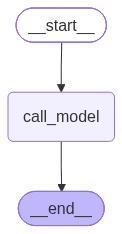

In [7]:
graph = builder.compile()
graph

In [9]:

graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Ansh."}]})

{'messages': [HumanMessage(content='Hi! My name is Ansh.', additional_kwargs={}, response_metadata={}, id='b159f6ba-f2f2-4cec-a505-a83896b15d29'),
  AIMessage(content='Hello Ansh! 👋 Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Ansh." It\'s a greeting. We respond politely, maybe ask how can help. Should follow OpenAI policy. No issues.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 79, 'total_tokens': 142, 'completion_time': 0.133061462, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.003686046, 'prompt_tokens_details': None, 'queue_time': 0.28307043, 'total_time': 0.136747508}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fadc0-260b-7ae3-b037-76ecb63ad768-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inp

In [10]:

graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='94b31870-5b33-4a73-a871-28ef6b5ef7b1'),
  AIMessage(content='I don’t have any information about your name. If you’d like me to address you by name, just let me know what it is!', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" There\'s no prior context. The assistant does not have that info. According to policy, we must respond that we don\'t know the name. We can ask politely for the name if needed. So answer: I don\'t know your name, could you tell me?'}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 76, 'total_tokens': 175, 'completion_time': 0.209965058, 'completion_tokens_details': {'reasoning_tokens': 61}, 'prompt_time': 0.004347091, 'prompt_tokens_details': None, 'queue_time': 0.285081304, 'total_time': 0.214312149}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3af2d41834', 'service_tier': 'on_demand', '

In [11]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [12]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [13]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [18]:

config = {"configurable": {"thread_id": "thread-1"}}
# config2 = {"configurable": {"thread_id": "thread-2"}}

In [19]:

graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Ansh."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Ansh.', additional_kwargs={}, response_metadata={}, id='1002f830-eb22-4129-a3c3-2bf773f134d1'),
  AIMessage(content='Hello Ansh! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Ansh." Likely a greeting. Should respond politely, maybe ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 79, 'total_tokens': 136, 'completion_time': 0.120964734, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.003213897, 'prompt_tokens_details': None, 'queue_time': 0.159680389, 'total_time': 0.124178631}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_84bf0227ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fadc0-c724-7b80-b171-d8ab574e8874-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 

In [20]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Ansh.', additional_kwargs={}, response_metadata={}, id='1002f830-eb22-4129-a3c3-2bf773f134d1'),
  AIMessage(content='Hello Ansh! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Ansh." Likely a greeting. Should respond politely, maybe ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 79, 'total_tokens': 136, 'completion_time': 0.120964734, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.003213897, 'prompt_tokens_details': None, 'queue_time': 0.159680389, 'total_time': 0.124178631}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_84bf0227ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fadc0-c724-7b80-b171-d8ab574e8874-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 79, 

In [22]:

snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Ansh.
- AIMessage : Hello Ansh! Nice to meet you. How can I assist you today?
- HumanMessage : Hi! My name is Ansh.
- AIMessage : Hello again, Ansh! 👋 How’s your day going? Let me know if there’s anything you’d like to talk about or need help with.
- HumanMessage : What is my name?
- AIMessage : Your name is Ansh.
